Kök Ortalama Kare Hata (RMSE): 47.47
Ortalama Mutlak Hata (MAE): 38.18


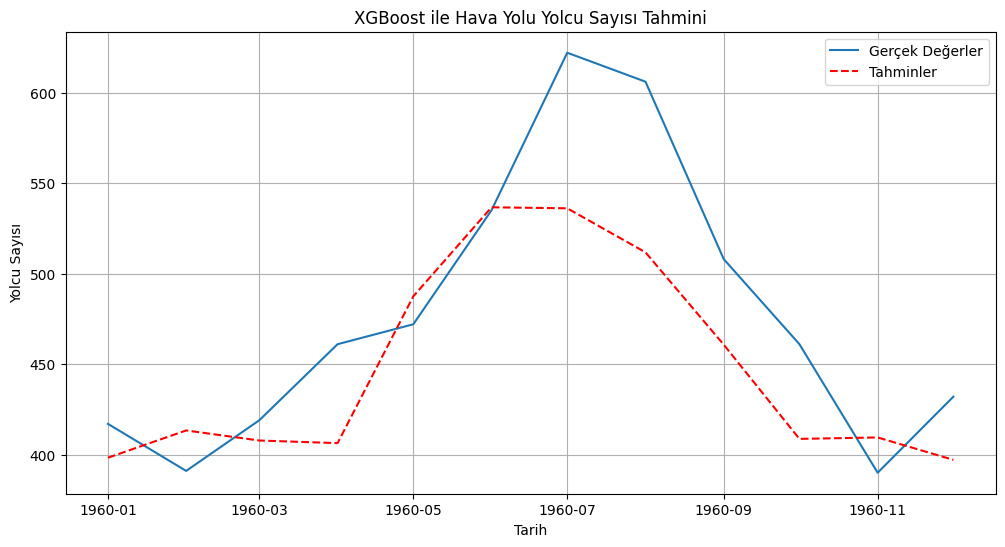

In [1]:
# Gerekli kütüphanelerin içeri aktarılması
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Veri Yükleme ve Hazırlama
# CSV dosyasını oku ve 'Month' sütununu tarih formatına çevir
df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month')

# 2. Özellik Mühendisliği (Feature Engineering)
# Modelin geleceği tahmin etmesine yardımcı olacak yeni özellikler oluşturma
# Geçmiş verileri kullanarak geleceği tahmin etmek için 'gecikme' (lag) özellikleri eklenir.
# lag_1: Bir ay önceki yolcu sayısı
# lag_2: İki ay önceki yolcu sayısı
df['lag_1'] = df['Passengers'].shift(1)
df['lag_2'] = df['Passengers'].shift(2)

# Mevsimselliği yakalamak için ay bilgisini sayısal bir özellik olarak ekle
df['month_index'] = df.index.month

# Gecikme özellikleri oluşturulduğunda ilk satırlarda oluşan boş (NaN) değerleri kaldır
df = df.dropna()

# 3. Veri Setini Ayırma
# Bağımsız değişkenler (X) ve hedef değişken (y) olarak veriyi ayır
X = df[['lag_1', 'lag_2', 'month_index']]
y = df['Passengers']

# Veri setini eğitim ve test olarak ikiye böl. Son 12 ay test için ayrılır.
split_point = len(df) - 12
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# 4. Model Oluşturma ve Eğitme
# XGBoost regresyon modelini belirli parametrelerle oluştur
reg = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)

# Modeli eğitim verileriyle eğit
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False) # Eğitim sürecindeki detaylı çıktıları kapat

# 5. Tahmin ve Değerlendirme
# Eğitilmiş model ile test verileri üzerinde tahmin yap
y_pred = reg.predict(X_test)

# Modelin performansını ölçmek için hata metriklerini hesapla
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Kök Ortalama Kare Hata (RMSE): {rmse:.2f}")
print(f"Ortalama Mutlak Hata (MAE): {mae:.2f}")

# 6. Sonuçları Görselleştirme
# Gerçek değerler ile tahminleri karşılaştıran bir grafik çiz
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Gerçek Değerler')
plt.plot(y_test.index, y_pred, label='Tahminler', linestyle='--', color='red')
plt.title('XGBoost ile Hava Yolu Yolcu Sayısı Tahmini')
plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı')
plt.legend()
plt.grid(True)
plt.show()